In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
# 1. Loading dataset from computer
house = pd.read_csv('housing.csv')
print("First few rows of the dataset:")
print(house.head())

First few rows of the dataset:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [28]:
# Extract input (X) and output (Y)
# Assuming 'median_house_value' is the target variable
X = house.drop('median_house_value', axis=1)
y = house['median_house_value']

In [29]:
# 2. Handle missing values
# Filling NaNs with the mean.
X = X.fillna(X.mean(numeric_only=True))



In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 3. Encode categorical data
# Assuming 'ocean_proximity' is the categorical column
label_house = LabelEncoder()
for column in X.columns:
    if X[column].dtype == 'object':
        X[column] = label_house.fit_transform(X[column])

In [31]:
# 4. Split the dataset (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

# 5. Standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
from sklearn.linear_model import LinearRegression

linear = LinearRegression().fit(X_train_scaled, y_train)
predicters = linear.predict(X_test_scaled)
models = {"Linear Regression": LinearRegression(),}

from sklearn.metrics import mean_squared_error

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    print(f"{name} RMSE: {rmse:.2f}")

Linear Regression RMSE: 69321.01


In [33]:
from sklearn.tree import DecisionTreeRegressor

decisiomtree = DecisionTreeRegressor().fit(X_train_scaled, y_train)
predicters = decisiomtree.predict(X_test_scaled)
models = {"Decision Tree": DecisionTreeRegressor()}

from sklearn.metrics import mean_squared_error

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    print(f"{name} RMSE: {rmse:.2f}")

Decision Tree RMSE: 69416.88


In [34]:
from sklearn.ensemble import RandomForestRegressor

random = RandomForestRegressor().fit(X_train_scaled, y_train)
predicters = random.predict(X_test_scaled)


In [35]:
model = {"Random Forest": RandomForestRegressor(n_estimators=100)}

In [36]:
from sklearn.metrics import mean_squared_error

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    print(f"{name} RMSE: {rmse:.2f}")

Decision Tree RMSE: 69305.94


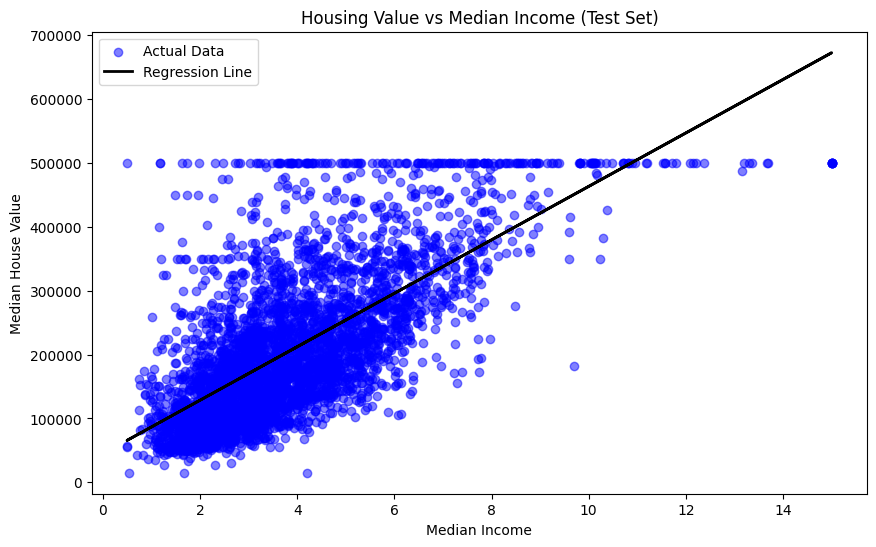

In [37]:
X_train_income = X_train[['median_income']]
X_test_income = X_test[['median_income']]

# Fit model
bonus_model = LinearRegression()
bonus_model.fit(X_train_income, y_train)
bonus_pred = bonus_model.predict(X_test_income)

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(X_test_income, y_test, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_test_income, bonus_pred, color='black', linewidth=2, label='Regression Line')
plt.title('Housing Value vs Median Income (Test Set)')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.show()